In [11]:
import pandas as pd
import os
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.SeqIO import write
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
##table S2 with the motifs from Moses 2012
df_xls = pd.read_excel('Moses_data/2002515_tableS2.xls', header=2)
#all the proteins from the yeast http://sgd-archive.yeastgenome.org/sequence/S288C_reference/orf_protein/
orf_dict = SeqIO.to_dict(SeqIO.parse('Moses_data/orf_trans_all.fasta', 'fasta'))


In [13]:
df_xls = pd.read_csv('PhyloHMM_dataset.csv')

### check if the motifs from tableS2 correspond to the subsequeces from orf_trans_all.fasta

In [3]:
##Correction to the table S2 provided by Moses, verified articles indentified by PMID
df_xls.loc[373, 'Stop']=13
df_xls.loc[375, 'Sequence'] = 'MSHRKYEAPRHGHLGFLPRKR'
df_xls.loc[376, 'Stop']=831
df_xls.loc[245,'Start']=357
df_xls.loc[245,'Stop']=357
df_xls.loc[182, 'Stop'] = 32

In [4]:
for index, row in df_xls.iterrows():
    gene_name = row['Gene ORF']
    motif = row['Sequence']
    start, stop = row['Start'], row['Stop']
    print(gene_name, motif, start, stop)

    if gene_name in orf_dict:
        seq = orf_dict[gene_name].seq
        print(seq[int(start)-1:int(stop)], seq[int(start)-1:int(stop)]==motif)
        if seq[int(start)-1:int(stop)]!=motif:
            print(index)
        #df_xls.at[index, 'Sequence'] = str(seq)
    else:
        print(f"Gene {gene_name} not found in the ORF dictionary.")
        # If you want to set the Sequence to None when the gene is not found, uncomment the next line
        #df_xls.at[index, 'Sequence'] = None

YKL112W SKRQH 624 628
SKRQH True
YKL112W DEEDLSDENIQPE 715 727
DEEDLSDENIQPE True
YLR131C HKRGLS 117 122
HKRGLS True
YLR131C HNKTLS 132 137
HNKTLS True
YLR131C HKKRES 431 436
HKKRES True
YPL267W SPSK 3 6
SPSK True
YPL267W SPSK 31 34
SPSK True
YPL267W SPIK 48 51
SPIK True
YPL267W KEN 98 100
KEN True
YPL267W SPAK 102 105
SPAK True
YPL267W RIAL 119 122
RIAL True
YPL267W TPPR 161 164
TPPR True
YGL071W KPKKKR 202 207
KPKKKR True
YGL071W SKRP 332 335
SKRP True
YGL071W RKPK 352 355
RKPK True
YGL021W KEN 200 202
KEN True
YGL021W RTPLKPLVN 224 232
RTPLKPLVN True
YBL009W KEN 116 118
KEN True
YBL009W RTPLRPISN 150 158
RTPLRPISN True
YOR058C S 337 337
S True
YOR058C T 524 524
T True
YOR058C T 680 680
T True
YOR058C T 733 733
T True
YOR058C S 809 809
S True
YKL052C S 200 200
S True
YBR200W SPEK 72 75
SPEK True
YJR053W PLTLN 5 9
PLTLN True
YJR053W ETSFE 15 19
ETSFE True
YJR053W NTTLP 22 26
NTTLP True
YJR053W FQSHE 28 32
FQSHE True
YJR053W TLTLE 33 37
TLTLE True
YJR053W TSTYI 45 49
TSTYI True
YJR053W

In [ ]:
## take the name of the genes with the motifs to run CF+ProteoCast
l_yeast_proteins = df_xls['Gene ORF'].unique().tolist()
# Filter orf_dict to only include entries whose keys are in l_yeast_proteins
filtered_records = [orf_dict[orf] for orf in l_yeast_proteins if orf in orf_dict]

# Write to a fasta file
with open("Moses_data/filtered_yeast_proteins.fasta", "w") as fasta_out:
    write(filtered_records, fasta_out, "fasta")

In [55]:
' '.join(l_yeast_proteins)


'YKL112W YLR131C YPL267W YGL071W YGL021W YBL009W YOR058C YKL052C YBR200W YJR053W YNL271C YGR140W YCR002C YDL220C YKL022C YAL038W YGL116W YHR166C YAL041W YBL084C YBR160W YDR054C YLR103C YMR001C YJL194W YGL003C YBR274W YER026C YOR028C YEL061C YLR133W YPR119W YAL040C YNL225C YNL027W YGR113W YNL118C YPR175W YDR446W YDL161W YJL157C YDR130C YNL068C YLL043W YBR021W YMR232W YEL009C YBR045C YER040W YLR258W YBR009C YNL030W YBR010W YNL031C YCL067C YOL123W YKL101W YPL240C YDR225W YDR224C YGL253W YOR189W YJL106W YPL209C YHR079C YBL063W YDR499W YDR034C YJL013C YDR005C YCR039C YDL003W YIL150C YBL023C YEL032W YPR019W YDL005C YKL089W YGL035C YMR036C YBR098W YOR274W YDL028C YCL061C YMR037C YDR208W YKL129C YKR048C YOR372C YLR265C YJL076W YCL017C YDR432W YHL020C YBR060C YHR118C YIR006C YJL128C YHR071W YDR113C YMR205C YIL107C YDL106C YFR034C YBL105C YGL008C YNR052C YOR362C YIL095W YDR496C YJR035W YML032C YPL153C YDR076W YDR217C YLR248W YKL159C YJR021C YNL312W YDR379W YFL033C YOR119C YMR235C YMR239C YOL127W

In [149]:
df_xls['Function'].value_counts(), 431/526

(Function
 Phosphorylation Site    431
 Localization Signal      71
 Degradation Signal       13
 SUMO site                 8
 Interaction Motif         3
 Name: count, dtype: int64,
 0.8193916349809885)

In [145]:
df_xls.loc[(df_xls['Present in disordered regions']==True)].shape, 352/526

((352, 14), 0.6692015209125475)

In [8]:
df_mapping = pd.read_csv('Moses_data/mapping.txt', sep=' ', header=None, names=['Gene ORF', 'Gene ID'])
df_mapping

,Gene ORF,Gene ID
0,YKL112W,0
1,YLR131C,1
2,YPL267W,2
3,YGL071W,3
4,YGL021W,4
...,...,...
169,YGR184C,169
170,YCL063W,170
171,YOR083W,171
172,YML007W,172


In [ ]:
def get_state_for_position(df, position, metric='state', type='GEMME'):
    row = df[(df['start'] <= position) & (df['end'] >= position)&(df['type']==type)]
    if not row.empty:
        return round(row.iloc[0][metric], 3)
    return None

In [39]:
def get_mean_proteo(df_proteo, position):
    return np.mean(df_proteo.loc[df_proteo['Residue'].isin(position), 'GEMME_mean']).round(2)

In [7]:
df_xls.rename(columns={'Predicted by the phylo-HMM (* indicates that this motif was not counted in the predictions because they overlap with another motif)': 'Phylo_HMM'}, inplace=True)

### add ProteoCast predictions

In [41]:
for index, row in df_xls.iterrows():
    
    gene_id = df_mapping.loc[df_mapping['Gene ORF'] == row['Gene ORF'], 'Gene ID'].values[0]
    start, stop = row['Start'], row['Stop']
    sequence = row['Sequence']
    positions = list(np.arange(start, stop+1))
    try:
        df_plddt = pd.read_csv(f'Moses_data/YEAST_MOSES/{str(gene_id)}/14.101_GEMME_pLDDT.csv', sep=',')       
        df_segments = pd.read_csv(f'Moses_data/YEAST_MOSES/{str(gene_id)}/8.101_Segmentation.csv', sep=',')
        df_proteocast = pd.read_csv(f'Moses_data/YEAST_MOSES/{str(gene_id)}/14.101_GEMME_pLDDT.csv', sep=',')
        l_localSens = [get_state_for_position(df_segments, pos) for pos in positions]
        mean_plddt = df_plddt.loc[start:stop, 'pLDDT'].mean()
        df_xls.loc[index, 'ProteoCast_LocalSens'] = round(np.sum(np.isin(l_localSens, [1, 2])) / len(l_localSens), 2)
        df_xls.loc[index, 'ProteoCast_GEMMEmean'] = get_mean_proteo(df_proteocast, positions)
        df_xls.loc[index, 'pLDDT_mean'] = mean_plddt 
        
    except FileNotFoundError:
        #print(f"File not found: Moses_data/YEAST_MOSES/{str(gene_id)}/14.101_GEMME_pLDDT.csv")
        continue
    

### add Length

In [132]:
df_xls['Length'] = df_xls['Stop'] - df_xls['Start'] + 1

### add Global Conf

In [175]:
df_proteocast['LocalConfidence'].unique()[0]

True

In [181]:
df_xls['ProteoCast_GlobalConf'] = True
for prot in df_xls['Gene ORF'].unique():
    gene_id = df_mapping.loc[df_mapping['Gene ORF'] == prot, 'Gene ID'].values[0]
    try:
        df_proteocast = pd.read_csv(f'Moses_data/YEAST_MOSES/{str(gene_id)}/4.101_ProteoCast.csv', sep=',')
        if df_proteocast['LocalConfidence'].nunique()==1 and df_proteocast['LocalConfidence'].unique()[0]==False:
            df_xls.loc[df_xls['Gene ORF'] == prot, 'ProteoCast_GlobalConf'] = False
    except:
        continue

### add Local Conf

In [164]:
df_xls['ProteoCast_LocalConf'] = None 
for index, row in df_xls.iterrows():
    gene_id = df_mapping.loc[df_mapping['Gene ORF'] == row['Gene ORF'], 'Gene ID'].values[0]
    start, stop = row['Start'], row['Stop']
    sequence = row['Sequence']
    positions = list(np.arange(start, stop+1))
    try:
        df_proteocast = pd.read_csv(f'Moses_data/YEAST_MOSES/{str(gene_id)}/4.101_ProteoCast.csv', sep=',')
        local_conf = df_proteocast.loc[df_proteocast['Residue'].isin(positions), 'LocalConfidence'].values
        df_xls.loc[df_xls['Gene ORF'] == row['Gene ORF'], 'ProteoCast_LocalConf'] = (sum(local_conf)/len(local_conf)).round(2)
    except:
        continue


## Performance

In [6]:
df_xls_done = df_xls.loc[~df_xls['ProteoCast_LocalSens'].isnull()].copy()
df_xls_done['Length'] = df_xls_done['Stop'] - df_xls_done['Start'] + 1
print('Number of segments', df_xls_done.shape[0], '\n',
      'segments in phylo HMM disorder', df_xls_done.loc[(df_xls_done['Present in disordered regions']==True)].shape[0], df_xls_done.loc[(df_xls_done['Present in disordered regions']==True), 'Gene ORF'].nunique(), '\n',
      'pLDDT<70', df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7)].shape[0], df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7), 'Gene ORF'].nunique(), '\n',
      'both', df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7)&(df_xls_done['Present in disordered regions']==True)].shape[0], 
      df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7)&(df_xls_done['Present in disordered regions']==True), 'Gene ORF'].nunique())

df_xls_done_plddt = df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7)&(df_xls_done['Present in disordered regions']==True)].copy()
#df_xls_done_plddt = df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7)].copy()

Number of segments 521 
 segments in phylo HMM disorder 347 113 
 pLDDT<70 437 146 
 both 333 112


### write a dataframe where ProteoCast identify the sites and phyloHMM not

In [189]:
df_xls_done_plddt.loc[(df_xls_done_plddt["ProteoCast_LocalSens"] == 1.0)&(df_xls_done_plddt['Phylo_HMM']==False)].sort_values(['ProteoCast_GEMMEmean'], ascending=True).to_csv('PhyloHMM_ProteoDetectOnly.csv', index=False)

### plot the segmentation plots with the phylHMM sites in red

In [ ]:
segments_grouped = df_xls_done.groupby('Gene ORF')


for protein, group in segments_grouped:
    id_prot = df_mapping[df_mapping['Gene ORF'] == protein]['Gene ID'].values[0]
    data = pd.read_csv(f'Moses_data/YEAST_MOSES/{str(id_prot)}/14.101_GEMME_pLDDT.csv', sep=',')
    
    signal = pd.DataFrame({
        'x': list(range(1, len(data) + 1)),
        'y': list(data['GEMME_mean']),
        'type': ['GEMME'] * len(data)
    })
    gemme = pd.read_csv(f'Moses_data/YEAST_MOSES/{str(id_prot)}/8.101_Segmentation.csv', sep=',')
    gemme = gemme[gemme['type'] == 'GEMME']

    cp = pd.DataFrame({
        'x': list(gemme['end'][:-1]),'type': ['GEMME'] * (len(gemme) - 1)})
    mean = pd.DataFrame({
        'x': list(gemme['start'] - 1),'xend': list(gemme['end']),
        'y': list(gemme['mean']),'type': ['GEMME'] * len(gemme),
        'state': list(gemme['state'])
    })
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 5), gridspec_kw={'height_ratios': [1, 6]})
    # Plot GEMME on the top subplot
    for _, row in mean[mean['type'] == 'GEMME'].iterrows():
        ax2.axvspan(row['x'], row['xend'], color='white' if row['state'] == 0 else 'red' if row['state'] == 1 else 'purple', alpha=0.1)
    ax2.plot(signal[signal['type'] == 'GEMME']['x'], signal[signal['type'] == 'GEMME']['y'], label='GEMME', linewidth=1.3)

    for _, row in cp[cp['type'] == 'GEMME'].iterrows():
        ax2.axvline(row['x'], color='red', alpha=0.9, linewidth=1.3)
    for _, row in mean[mean['type'] == 'GEMME'].iterrows():
        ax2.plot([row['x'], row['xend']], [row['y'], row['y']], color='black',linewidth=1, alpha=0.75)

    ax2.set_ylabel('Mutational sensitivity', fontsize=17, labelpad=10)

    for start, stop in group[['Start', 'Stop']].values:
        positions = list(np.arange(start, stop+1))
        ax2.hlines(y=0.8, xmin=positions[0]-0.5, xmax=positions[-1]+0.5, colors='red', linewidth=6, label='Binding=1 (y=0.8)')

    
    palette_bis={0:'#FF7D45', 1:'#FFDB13', 2:'#65CBF3', 3:'#0053D6'}
    bins = [0, 50, 70, 90, 100]
    df = pd.DataFrame(list(data['pLDDT']*100), columns=['value'])
    # Bin the values into groups
    df['group'] = pd.cut(df['value'], bins=bins, labels=[0,1,2,3], right=False)
    grouped_values_numeric = np.array(df['group'])

    # Reshape to a one-row matrix with 395 columns
    data_matrix = grouped_values_numeric.reshape(1, -1)

    # Map the palette to colors for the heatmap
    colors = [palette_bis[val] for val in sorted(palette_bis.keys())]
    cmap = sns.color_palette(colors, len(colors))
    sns.heatmap(data_matrix, cmap=cmap, linewidths=0, cbar=False, xticklabels=False, yticklabels=False, alpha=0.85, ax=ax1)


    # Adjust xticks for ax2
    xticks = range(50, signal.shape[0] + 1, 50)
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([str(x) for x in xticks], fontsize=15)
    ax2.set_yticklabels([str(round(x, 1)) for x in ax2.get_yticks()], fontsize=15)

    # Remove x-axis ticks and labels from ax1
    ax1.set_xticks([])
    ax1.set_xticklabels([])

    ax1.set_xlim(1, signal.shape[0])
    ax2.set_xlim(1, signal.shape[0])


    plt.xlabel('Residue index', fontsize=20, labelpad=12)
    plt.subplots_adjust(hspace=0.05)
    #fig.suptitle(protein, fontsize=17, y=0.95)
    plt.tight_layout()
    #plt.show()
    plt.savefig('Moses_data/YEAST_MOSES/plots/' + protein + '.jpg', dpi=500)
    plt.close(fig)


### set 1 ['Present in disordered regions']==True

In [ ]:
df_tmp = df_xls_done.loc[(df_xls_done['Present in disordered regions']==True)].copy()

print("#genes/sequences in unstructured regions", df_tmp['Gene Name'].nunique())
print(f'# Segments: {df_tmp.shape[0]}')
print(f' Local Sensitivity (at least 1 residue): {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]}', round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]/df_tmp.shape[0] *100, 2), '%')
print(f'Local Sensitivity Segments full: {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0]} ({round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0] / df_tmp.shape[0] * 100, 2)}%)')
print(f'phyloHMM: {df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0]} ({round(df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0] / df_tmp.shape[0] * 100, 2)}%)')


#genes/sequences in unstructured regions 113
# Segments: 347
# Unstructured segments: 347 1.0
 Local Sensitivity (at least 1 residue): 175 50.43 %
Local Sensitivity Segments full: 132 (38.04%)
phyloHMM: 104 (29.97%)


### set 2 ['pLDDT_mean'] < 0.7)&(df_xls_done['Present in disordered regions']==True)]

In [ ]:
df_tmp = df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7)&(df_xls_done['Present in disordered regions']==True)].copy()

print("#genes/sequences in unstructured regions", df_tmp['Gene Name'].nunique())
print(f'# Segments: {df_tmp.shape[0]}')
print(f' Local Sensitivity (at least 1 residue): {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]}', round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]/df_tmp.shape[0] *100, 2), '%')
print(f'Local Sensitivity Segments full: {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0]} ({round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0] / df_tmp.shape[0] * 100, 2)}%)')
print(f'phyloHMM: {df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0]} ({round(df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0] / df_tmp.shape[0] * 100, 2)}%)')


#genes/sequences in unstructured regions 112
# Segments: 333
# Unstructured segments: 333 1.0
 Local Sensitivity (at least 1 residue): 169 50.75 %
Local Sensitivity Segments full: 127 (38.14%)
phyloHMM: 99 (29.73%)


### set 3 ['pLDDT_mean'] < 0.7

In [ ]:
df_tmp = df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7)].copy()

print("#genes/sequences in unstructured regions", df_tmp['Gene Name'].nunique())
print(f'# Segments: {df_tmp.shape[0]}')
print(f' Local Sensitivity (at least 1 residue): {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]}', round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]/df_tmp.shape[0] *100, 2), '%')
print(f'Local Sensitivity Segments full: {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0]} ({round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0] / df_tmp.shape[0] * 100, 2)}%)')
print(f'phyloHMM: {df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0]} ({round(df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0] / df_tmp.shape[0] * 100, 2)}%)')


#genes/sequences in unstructured regions 146
# Segments: 437
# Unstructured segments: 437 1.0
 Local Sensitivity (at least 1 residue): 240 54.92 %
Local Sensitivity Segments full: 186 (42.56%)
phyloHMM: 99 (22.65%)


### with confidence 

In [210]:
df_xls_done.loc[df_xls_done['ProteoCast_GlobalConf']==False, 'Gene ORF'].nunique()

28

In [214]:
df_xls_done.loc[df_xls_done['ProteoCast_LocalConf']==1.0].shape

(410, 18)

In [216]:
df_xls_done.shape

(521, 18)

In [215]:
df_xls_done.loc[df_xls_done['ProteoCast_LocalConf']==0.0, 'Gene ORF'].nunique()

32

In [207]:
df_xls.loc[df_xls['ProteoCast_LocalSens'].isnull(), 'ProteoCast_GlobalConf']=False

In [208]:
df_xls.to_csv('PhyloHMM_dataset.csv', index=False)

In [219]:
## set1
df_tmp = df_xls_done.loc[(df_xls_done['Present in disordered regions']==True)& (df_xls_done['ProteoCast_GlobalConf'] == True)].copy()

print("#genes/sequences in unstructured regions", df_tmp['Gene Name'].nunique())
print(f'# Segments: {df_tmp.shape[0]}')
print(f' Local Sensitivity (at least 1 residue): {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]}', round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]/df_tmp.shape[0] *100, 2), '%')
print(f'Local Sensitivity Segments full: {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0]} ({round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0] / df_tmp.shape[0] * 100, 2)}%)')
print(f'phyloHMM: {df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0]} ({round(df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0] / df_tmp.shape[0] * 100, 2)}%)')


#genes/sequences in unstructured regions 90
# Segments: 271
 Local Sensitivity (at least 1 residue): 134 49.45 %
Local Sensitivity Segments full: 103 (38.01%)
phyloHMM: 80 (29.52%)


In [221]:
df_xls_done['Length'].describe()

count    521.000000
mean       4.510557
std        5.553965
min        1.000000
25%        1.000000
50%        4.000000
75%        5.000000
max       61.000000
Name: Length, dtype: float64

In [218]:
##set 2
df_tmp = df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7) & (df_xls_done['ProteoCast_LocalConf'] == 1.0)].copy()

print("#genes/sequences in unstructured regions", df_tmp['Gene Name'].nunique())
print(f'# Segments: {df_tmp.shape[0]}')
print(f' Local Sensitivity (at least 1 residue): {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]}', round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]/df_tmp.shape[0] *100, 2), '%')
print(f'Local Sensitivity Segments full: {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0]} ({round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0] / df_tmp.shape[0] * 100, 2)}%)')
print(f'phyloHMM: {df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0]} ({round(df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0] / df_tmp.shape[0] * 100, 2)}%)')


#genes/sequences in unstructured regions 111
# Segments: 339
 Local Sensitivity (at least 1 residue): 186 54.87 %
Local Sensitivity Segments full: 150 (44.25%)
phyloHMM: 75 (22.12%)


In [ ]:
### set 3
df_tmp = df_xls_done_plddt.loc[(df_xls_done_plddt['ProteoCast_LocalConf'] == 1.0)].copy()

print("#genes/sequences in unstructured regions", df_tmp['Gene Name'].nunique())
print(f'# Segments: {df_tmp.shape[0]}')
print(f' Local Sensitivity (at least 1 residue): {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]}', round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] != 0.0].shape[0]/df_tmp.shape[0] *100, 2), '%')
print(f'Local Sensitivity Segments full: {df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0]} ({round(df_tmp.loc[df_tmp["ProteoCast_LocalSens"] == 1.0].shape[0] / df_tmp.shape[0] * 100, 2)}%)')
print(f'phyloHMM: {df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0]} ({round(df_tmp.loc[df_tmp["Phylo_HMM"] == True].shape[0] / df_tmp.shape[0] * 100, 2)}%)')


#genes/sequences in unstructured regions 81
# Segments: 248
 Local Sensitivity (at least 1 residue): 125 50.4 %
Local Sensitivity Segments full: 98 (39.52%)
phyloHMM: 75 (30.24%)


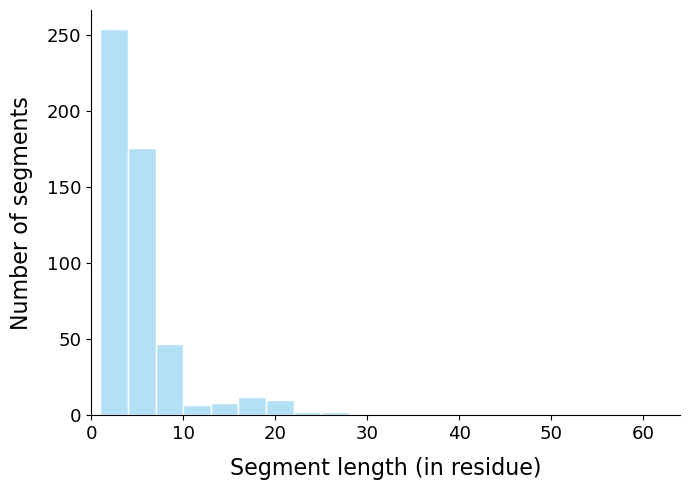

In [234]:

df_tmp = df_xls_done.copy() #df_xls_done.loc[(df_xls_done['pLDDT_mean'] < 0.7)]
plt.figure(figsize=(7, 5))
plt.hist(df_tmp['Length'], bins=20, edgecolor='white', color='#B4E0F7')
#plt.hist(df_CAID_segments['Length'], bins=20, edgecolor='black', alpha=0.5)
plt.xlabel('Segment length (in residue)', fontsize=16, labelpad=10)
plt.ylabel('Number of segments', fontsize=16, labelpad=10)
plt.grid(False)
plt.xlim(0)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('phyloHMM_segmentPLDDT70_length_distribution.jpg', dpi=700)
plt.show()


[  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100.]
[ 2.5  7.5 12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5 52.5 57.5 62.5 67.5
 72.5 77.5 82.5 87.5 92.5 97.5]


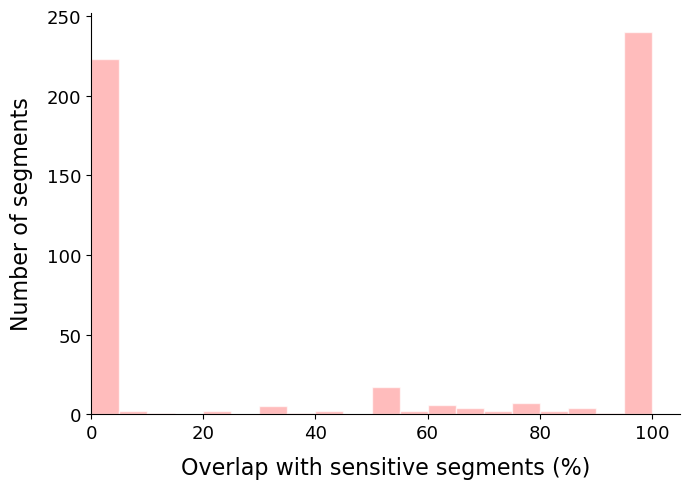

In [233]:
plt.figure(figsize=(7,5))
# Compute bin centers
bins = np.linspace(0, 100.0, 21)
counts, bins, _ = plt.hist(df_xls_done['ProteoCast_LocalSens']*100, bins=bins, edgecolor='white', color='#FF9999', alpha=0.65)
print(bins)
#plt.hist(df_CAID_segments['Length'], bins=20, edgecolor='black', alpha=0.5)
plt.xlabel('Overlap with sensitive segments (%)', fontsize=16, labelpad=10)
plt.ylabel('Number of segments', fontsize=16, labelpad=10)
plt.grid(False)
plt.xlim(0)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
print(bin_centers)
tick_positions = list(bin_centers[::4])
tick_labels = [f"{x:.1f}" for x in tick_positions]

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('phyloHMM_segmentUnstruct_localSensitivity.jpg', dpi=700)
plt.show()
